# Multi-Tissue T1/T2 GASP Training Analysis

This notebook explores training GASP models using data from **multiple tissue types (T1/T2 combinations)** combined, rather than a single tissue, with a focus on **cross-tissue generalization**.

## Motivation

Standard GASP training uses bSSFP data simulated for a single tissue type. However:
- Different tissues have different T1/T2 ratios producing different spectral responses
- Combining multiple tissue types may provide richer training data
- Multi-tissue training could improve generalization across all tissues

## Key Question

**Does training GASP with multiple T1/T2 combinations improve cross-tissue generalization?**

When we train GASP coefficients on multiple tissue types together, how well do those coefficients perform on different tissues compared to single-tissue training?

## Analysis Contents

1. **Understanding Multi-Tissue bSSFP Signals** - Visualize spectral responses for different T1/T2 ratios
2. **Multi-Tissue Training Setup** - Functions to combine data from multiple tissues
3. **Single vs Multi-Tissue Comparison** - Direct comparison of training approaches
4. **Method Comparison** - How linear, affine, quad, quad-cross methods perform
5. **Tissue Selection Strategies** - Which T1/T2 combinations work best
6. **Cross-Tissue Generalization Analysis** - The main analysis:
   - Train on tissue combinations, evaluate on others
   - Heatmaps of train tissue vs eval tissue
   - Best/worst fit examples
   - Residual spread analysis
7. **Method Comparison for Generalization** - All 4 methods compared
8. **Summary and Key Findings**

## Mathematical Background

### Standard GASP (Single Tissue)

For a single tissue with parameters $(T_1, T_2)$, we acquire bSSFP data with multiple phase cycles and TRs:

$$\mathbf{M} \in \mathbb{C}^{H \times W \times N} \quad \text{where } N = N_{\text{pcs}} \times N_{\text{TRs}}$$

### Multi-Tissue GASP

For multiple tissues with parameters $\{(T_1^{(k)}, T_2^{(k)})\}_{k=1}^{K}$, we concatenate training data:

$$\mathbf{M}_{\text{multi}} = [\mathbf{M}^{(1)}; \mathbf{M}^{(2)}; ...; \mathbf{M}^{(K)}]$$

The combined design matrix becomes:

$$\Phi_{\text{multi}} = [\Phi(\mathbf{M}^{(1)}); \Phi(\mathbf{M}^{(2)}); ...; \Phi(\mathbf{M}^{(K)})]$$

And we solve:

$$\Phi_{\text{multi}} \cdot \mathbf{A} = [\mathbf{D}; \mathbf{D}; ...; \mathbf{D}]$$

This trains coefficients that must work well across all included tissues.

In [22]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# GASP imports
from gasp import responses, simulation, tissue, ssfp
from gasp.gasp import train_gasp, run_gasp, _design_matrix, _to_matrix
from gasp.simulation import SSFPParams, simulate_ssfp, simulate_ssfp_sampling, simulate_ssfp_simple

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 11

## 1. Understanding Multi-Tissue bSSFP Signals

First, let's visualize how different T1/T2 combinations affect the bSSFP spectral response.

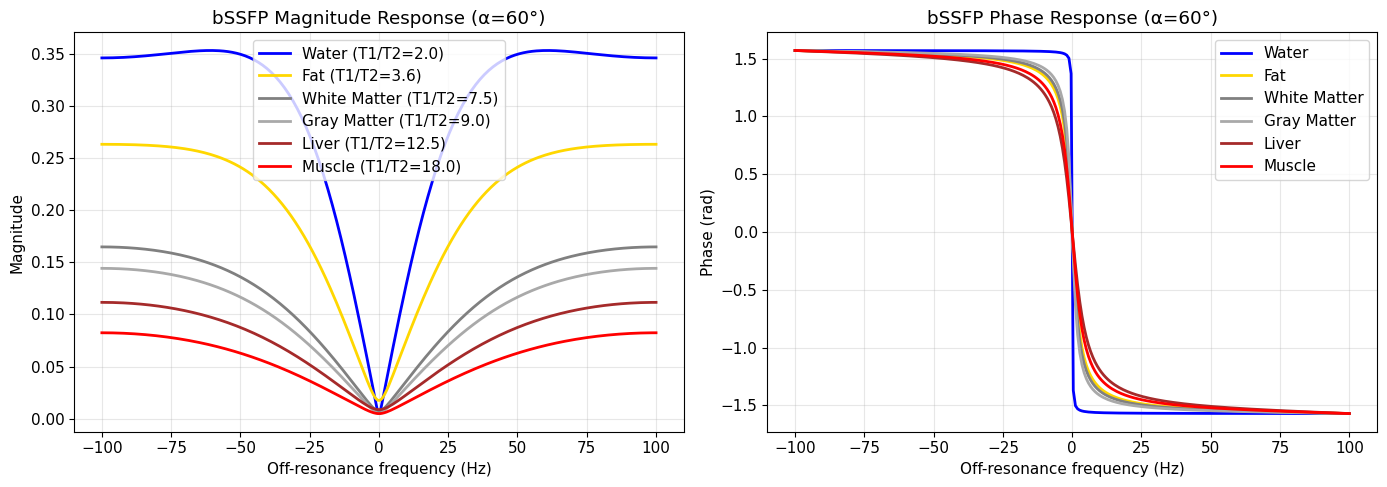

In [23]:
# Simulation parameters
width = 256
TR = 5e-3  # 5 ms
TE = TR / 2
pcs = [0]  # Single phase cycle for visualization
alpha_deg = 60  # Fixed flip angle
alpha = np.deg2rad(alpha_deg)

# Off-resonance frequency range
beta = np.linspace(-np.pi, np.pi, width)
f = beta / TR / (2 * np.pi)  # Convert to Hz

# Reference tissue types with realistic T1/T2 values at 1.5T
TISSUE_PARAMS = {
    'Water': {'T1': 4.0, 'T2': 2.0, 'color': 'blue'},
    'Fat': {'T1': 0.25, 'T2': 0.07, 'color': 'gold'},
    'White Matter': {'T1': 0.6, 'T2': 0.08, 'color': 'gray'},
    'Gray Matter': {'T1': 0.9, 'T2': 0.1, 'color': 'darkgray'},
    'Liver': {'T1': 0.5, 'T2': 0.04, 'color': 'brown'},
    'Muscle': {'T1': 0.9, 'T2': 0.05, 'color': 'red'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tissue_name, params in TISSUE_PARAMS.items():
    T1, T2 = params['T1'], params['T2']
    signal = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
    
    axes[0].plot(f, np.abs(signal).flatten(), label=f"{tissue_name} (T1/T2={T1/T2:.1f})", 
                 color=params['color'], linewidth=2)
    axes[1].plot(f, np.angle(signal).flatten(), label=tissue_name, 
                 color=params['color'], linewidth=2)

axes[0].set_xlabel('Off-resonance frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'bSSFP Magnitude Response (α={alpha_deg}°)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Off-resonance frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title(f'bSSFP Phase Response (α={alpha_deg}°)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

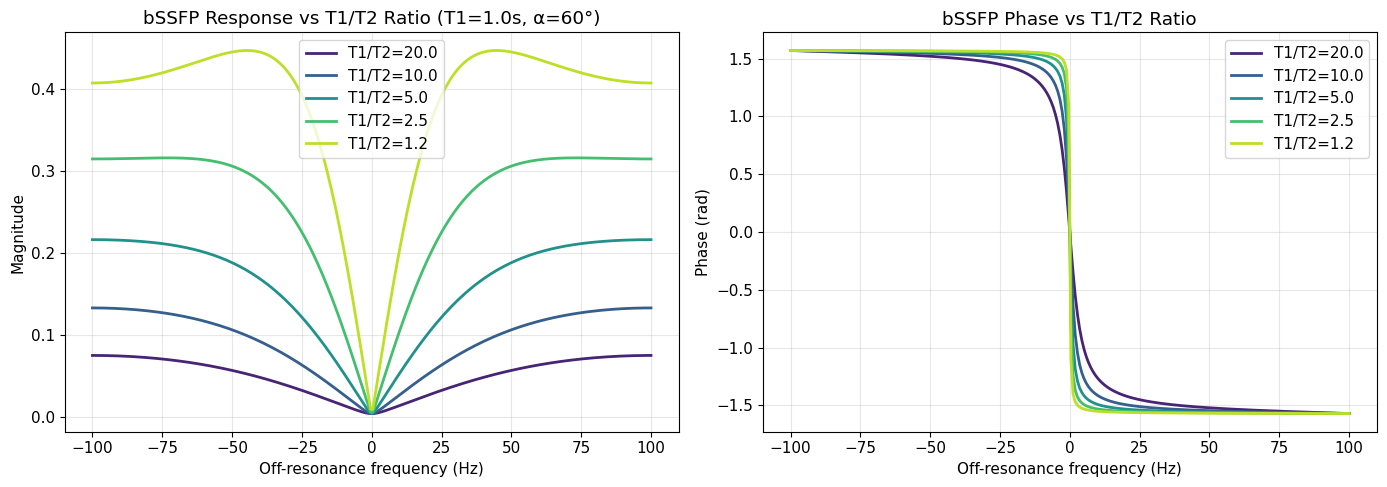

In [24]:
# Visualize T1/T2 ratio effect on spectral response
# Keep T1 fixed and vary T2 to see the effect of different ratios
T1_fixed = 1.0
T2_values = [0.05, 0.1, 0.2, 0.4, 0.8]  # Different T2 values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(T2_values)))

for T2, color in zip(T2_values, colors):
    ratio = T1_fixed / T2
    signal = ssfp.ssfp(T1_fixed, T2, TR, TE, alpha, pcs, field_map=f)
    
    axes[0].plot(f, np.abs(signal).flatten(), label=f"T1/T2={ratio:.1f}", color=color, linewidth=2)
    axes[1].plot(f, np.angle(signal).flatten(), label=f"T1/T2={ratio:.1f}", color=color, linewidth=2)

axes[0].set_xlabel('Off-resonance frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'bSSFP Response vs T1/T2 Ratio (T1={T1_fixed}s, α={alpha_deg}°)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Off-resonance frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title(f'bSSFP Phase vs T1/T2 Ratio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Multi-Tissue Training Setup

We'll create functions to generate training data from multiple tissues and combine them.

In [25]:
def create_params(alpha_deg, npcs, TRs):
    """Create SSFPParams for a given flip angle."""
    n_acq = npcs * len(TRs)
    pcs_list = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * n_acq
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs_list:
            TR_list.append(tr)
            pc_list.append(pc)
    
    return SSFPParams(n_acq, alpha_list, TR_list, pc_list)


def simulate_multi_tissue_data(width, height, npcs, TRs, alpha_deg, tissue_list):
    """
    Simulate bSSFP data for multiple tissues and concatenate.
    
    Args:
        width, height: Phantom dimensions
        npcs: Number of phase cycles
        TRs: List of TR values
        alpha_deg: Flip angle in degrees
        tissue_list: List of (T1, T2) tuples
    
    Returns:
        Combined data array with shape [n_tissues * height, width, npcs * n_TRs]
    """
    params = create_params(alpha_deg, npcs, TRs)
    all_data = []
    
    for T1, T2 in tissue_list:
        data = simulate_ssfp_simple(
            width=width, height=height,
            T1=T1, T2=T2,
            params=params,
            minTR=TRs[0]
        )
        all_data.append(data)
    
    # Concatenate along height dimension
    return np.concatenate(all_data, axis=0)


# Standard acquisition parameters
npcs = 4
TRs = [5e-3, 6e-3]
alpha_deg = 60
params = create_params(alpha_deg, npcs, TRs)

print(f"Acquisition parameters:")
print(f"  Flip angle: {alpha_deg}°")
print(f"  Phase cycles: {npcs}")
print(f"  TRs: {TRs}")
print(f"  Features per pixel: {npcs * len(TRs)} (complex)")

Acquisition parameters:
  Flip angle: 60°
  Phase cycles: 4
  TRs: [0.005, 0.006]
  Features per pixel: 8 (complex)


## 3. Single vs Multi-Tissue Training Comparison

Compare GASP performance when trained on single tissue vs multiple tissues combined.

In [26]:
# Target profile
D = responses.gaussian(width, bw=0.2, shift=0)
x = np.linspace(-1, 1, width)

# Define tissue configurations for training
SINGLE_TISSUES = {
    'Gray Matter': [(0.9, 0.1)],
    'White Matter': [(0.6, 0.08)],
    'Muscle': [(0.9, 0.05)],
}

MULTI_TISSUES = {
    'GM + WM': [(0.9, 0.1), (0.6, 0.08)],
    'GM + Muscle': [(0.9, 0.1), (0.9, 0.05)],
    'GM + WM + Muscle': [(0.9, 0.1), (0.6, 0.08), (0.9, 0.05)],
    'All Brain Tissues': [(0.9, 0.1), (0.6, 0.08), (4.0, 2.0)],  # GM + WM + CSF
    'Wide Range': [(0.9, 0.1), (0.6, 0.08), (0.9, 0.05), (0.25, 0.07)],  # GM + WM + Muscle + Fat
    'All 6 Tissues': [(4.0, 2.0), (0.25, 0.07), (0.6, 0.08), (0.9, 0.1), (0.5, 0.04), (0.9, 0.05)],  # Water, Fat, WM, GM, Liver, Muscle
}

# Combine all configurations
configs = {**SINGLE_TISSUES, **MULTI_TISSUES}

method = 'affine'

# Evaluation tissues
EVAL_TISSUES = [
    ('Water', 4.0, 2.0),
    ('Fat', 0.25, 0.07),
    ('White Matter', 0.6, 0.08),
    ('Gray Matter', 0.9, 0.1),
    ('Liver', 0.5, 0.04),
    ('Muscle', 0.9, 0.05),
]

print(f"Training configurations:")
for name, tissues in configs.items():
    ratios = [f"T1/T2={t1/t2:.1f}" for t1, t2 in tissues]
    print(f"  {name}: {', '.join(ratios)}")

print(f"\nEvaluation tissues: {[t[0] for t in EVAL_TISSUES]}")

Training configurations:
  Gray Matter: T1/T2=9.0
  White Matter: T1/T2=7.5
  Muscle: T1/T2=18.0
  GM + WM: T1/T2=9.0, T1/T2=7.5
  GM + Muscle: T1/T2=9.0, T1/T2=18.0
  GM + WM + Muscle: T1/T2=9.0, T1/T2=7.5, T1/T2=18.0
  All Brain Tissues: T1/T2=9.0, T1/T2=7.5, T1/T2=2.0
  Wide Range: T1/T2=9.0, T1/T2=7.5, T1/T2=18.0, T1/T2=3.6
  All 6 Tissues: T1/T2=2.0, T1/T2=3.6, T1/T2=7.5, T1/T2=9.0, T1/T2=12.5, T1/T2=18.0

Evaluation tissues: ['Water', 'Fat', 'White Matter', 'Gray Matter', 'Liver', 'Muscle']


In [27]:
# Run training and evaluation for each configuration
results = {}

for config_name, tissue_list in configs.items():
    # Simulate training data (combine all tissues)
    train_data = simulate_multi_tissue_data(
        width=width, height=1, npcs=npcs, TRs=TRs, 
        alpha_deg=alpha_deg, tissue_list=tissue_list
    )
    
    # Target for all tissues combined
    D_train = np.tile(D, (len(tissue_list), 1))
    
    # Train GASP - returns (reconstruction, coefficients)
    _, coeffs = train_gasp(train_data, D_train, method=method, useL2=True, lam=1e-2)
    
    # Evaluate on all test tissues
    eval_rmses = []
    eval_outputs = []
    
    for tissue_name, T1, T2 in EVAL_TISSUES:
        eval_data = simulate_ssfp_simple(
            width=width, height=1, T1=T1, T2=T2, params=params, minTR=TRs[0]
        )
        output = run_gasp(eval_data, coeffs, method=method)
        rmse = np.sqrt(np.mean((np.abs(output).flatten() - D) ** 2))
        eval_rmses.append(rmse)
        eval_outputs.append(np.abs(output).flatten())
    
    results[config_name] = {
        'coeffs': coeffs,
        'rmses': eval_rmses,
        'outputs': eval_outputs,
        'mean_rmse': np.mean(eval_rmses),
        'std_rmse': np.std(eval_rmses),
        'n_tissues': len(tissue_list),
    }
    
    print(f"{config_name}: Mean RMSE = {np.mean(eval_rmses):.4f} ± {np.std(eval_rmses):.4f}")

Gray Matter: Mean RMSE = 0.2824 ± 0.2853
White Matter: Mean RMSE = 0.2448 ± 0.2131
Muscle: Mean RMSE = 0.5179 ± 0.4696
GM + WM: Mean RMSE = 0.2702 ± 0.2683
GM + Muscle: Mean RMSE = 0.3415 ± 0.3641
GM + WM + Muscle: Mean RMSE = 0.2916 ± 0.3046
All Brain Tissues: Mean RMSE = 0.1822 ± 0.0589
Wide Range: Mean RMSE = 0.1940 ± 0.0886
All 6 Tissues: Mean RMSE = 0.1806 ± 0.0500


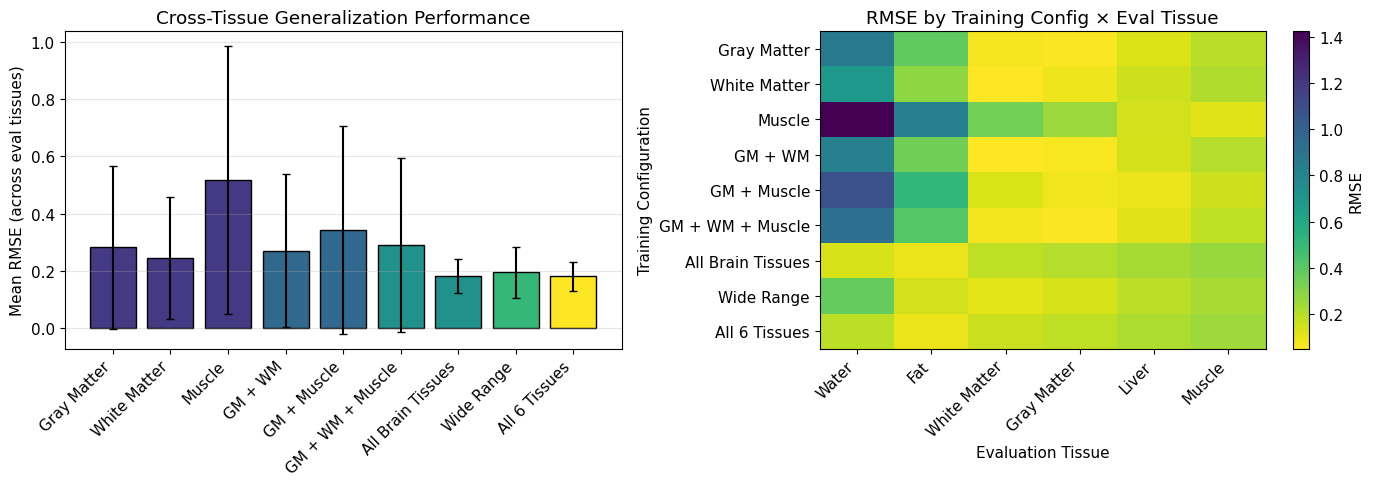

In [28]:
# Bar chart comparison - Generalization Performance
names = list(results.keys())
mean_rmses = [results[n]['mean_rmse'] for n in names]
std_rmses = [results[n]['std_rmse'] for n in names]
n_tissues = [results[n]['n_tissues'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by number of training tissues
colors = plt.cm.viridis(np.array(n_tissues) / max(n_tissues))

# Mean RMSE comparison with error bars
bars = axes[0].bar(range(len(names)), mean_rmses, yerr=std_rmses, color=colors, 
                   edgecolor='black', capsize=3)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_ylabel('Mean RMSE (across eval tissues)')
axes[0].set_title('Cross-Tissue Generalization Performance')
axes[0].grid(axis='y', alpha=0.3)

# Per-tissue RMSE heatmap
rmse_matrix = np.array([results[n]['rmses'] for n in names])
im = axes[1].imshow(rmse_matrix, cmap='viridis_r', aspect='auto')
axes[1].set_xticks(range(len(EVAL_TISSUES)))
axes[1].set_xticklabels([t[0] for t in EVAL_TISSUES], rotation=45, ha='right')
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels(names)
axes[1].set_xlabel('Evaluation Tissue')
axes[1].set_ylabel('Training Configuration')
axes[1].set_title('RMSE by Training Config × Eval Tissue')
plt.colorbar(im, ax=axes[1], label='RMSE')

plt.tight_layout()
plt.show()

## 4. Method Comparison with Multi-Tissue Training

Compare all four methods (linear, affine, quad, quad-cross) with multi-tissue training.

In [29]:
methods = ['linear', 'affine', 'quad', 'quad-cross']
tissue_configs = {
    'Single (GM)': [(0.9, 0.1)],
    'Dual (GM+WM)': [(0.9, 0.1), (0.6, 0.08)],
    'Triple (GM+WM+Muscle)': [(0.9, 0.1), (0.6, 0.08), (0.9, 0.05)],
}

# Mean RMSE matrix: [tissue_config, method]
mean_rmse_matrix = np.zeros((len(tissue_configs), len(methods)))
std_rmse_matrix = np.zeros((len(tissue_configs), len(methods)))

for i, (config_name, tissue_list) in enumerate(tissue_configs.items()):
    for j, method in enumerate(methods):
        # Simulate training data
        train_data = simulate_multi_tissue_data(
            width=width, height=1, npcs=npcs, TRs=TRs,
            alpha_deg=alpha_deg, tissue_list=tissue_list
        )
        D_train = np.tile(D, (len(tissue_list), 1))
        
        # Train - returns (reconstruction, coefficients)
        _, coeffs = train_gasp(train_data, D_train, method=method, useL2=True, lam=1e-2)
        
        # Evaluate
        rmses = []
        for tissue_name, T1, T2 in EVAL_TISSUES:
            eval_data = simulate_ssfp_simple(
                width=width, height=1, T1=T1, T2=T2, params=params, minTR=TRs[0]
            )
            output = run_gasp(eval_data, coeffs, method=method)
            rmse = np.sqrt(np.mean((np.abs(output).flatten() - D) ** 2))
            rmses.append(rmse)
        
        mean_rmse_matrix[i, j] = np.mean(rmses)
        std_rmse_matrix[i, j] = np.std(rmses)

print("Mean RMSE by (Tissue Config × Method):")
print(f"{'Config':<25} | " + " | ".join([f"{m:<12}" for m in methods]))
print("-" * 80)
for i, config_name in enumerate(tissue_configs.keys()):
    row = " | ".join([f"{mean_rmse_matrix[i,j]:.4f} ± {std_rmse_matrix[i,j]:.3f}" for j in range(len(methods))])
    print(f"{config_name:<25} | {row}")

Mean RMSE by (Tissue Config × Method):
Config                    | linear       | affine       | quad         | quad-cross  
--------------------------------------------------------------------------------
Single (GM)               | 0.3580 ± 0.135 | 0.2824 ± 0.285 | 0.2548 ± 0.266 | 0.3197 ± 0.376
Dual (GM+WM)              | 0.3527 ± 0.128 | 0.2702 ± 0.268 | 0.2329 ± 0.233 | 0.2744 ± 0.303
Triple (GM+WM+Muscle)     | 0.3712 ± 0.159 | 0.2916 ± 0.305 | 0.2647 ± 0.288 | 0.2643 ± 0.295


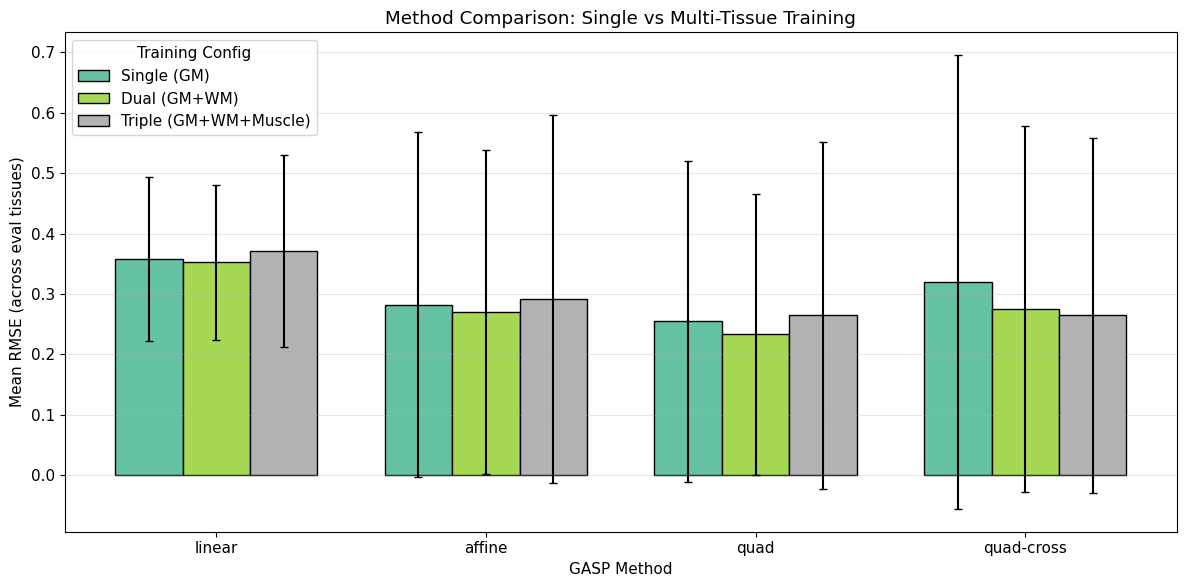

In [30]:
# Visualization: Bar chart grouped by method
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(methods))
width_bar = 0.25
colors = plt.cm.Set2(np.linspace(0, 1, len(tissue_configs)))

for i, (config_name, _) in enumerate(tissue_configs.items()):
    offset = (i - len(tissue_configs)/2 + 0.5) * width_bar
    bars = ax.bar(x + offset, mean_rmse_matrix[i, :], width_bar, 
                  yerr=std_rmse_matrix[i, :], label=config_name, 
                  color=colors[i], edgecolor='black', capsize=3)

ax.set_xlabel('GASP Method')
ax.set_ylabel('Mean RMSE (across eval tissues)')
ax.set_title('Method Comparison: Single vs Multi-Tissue Training')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend(title='Training Config')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Tissue Selection Strategies

Analyze which combinations of T1/T2 values work best for training.

In [31]:
from itertools import combinations

# Available tissues for combination analysis
AVAILABLE_TISSUES = [
    ('Water', 4.0, 2.0),
    ('Fat', 0.25, 0.07),
    ('WM', 0.6, 0.08),
    ('GM', 0.9, 0.1),
    ('Liver', 0.5, 0.04),
    ('Muscle', 0.9, 0.05),
]

method = 'affine'

def evaluate_tissue_combo(tissue_combo, method, D, npcs, TRs, alpha_deg, eval_tissues):
    """Train on tissue combo, evaluate on all tissues."""
    tissue_list = [(t[1], t[2]) for t in tissue_combo]
    
    # Train
    train_data = simulate_multi_tissue_data(
        width=width, height=1, npcs=npcs, TRs=TRs,
        alpha_deg=alpha_deg, tissue_list=tissue_list
    )
    D_train = np.tile(D, (len(tissue_list), 1))
    _, coeffs = train_gasp(train_data, D_train, method=method, useL2=True, lam=1e-2)
    
    # Evaluate
    params = create_params(alpha_deg, npcs, TRs)
    rmses = []
    for tissue_name, T1, T2 in eval_tissues:
        eval_data = simulate_ssfp_simple(width=width, height=1, T1=T1, T2=T2, params=params, minTR=TRs[0])
        output = run_gasp(eval_data, coeffs, method=method)
        rmse = np.sqrt(np.mean((np.abs(output).flatten() - D) ** 2))
        rmses.append(rmse)
    
    return {'mean': np.mean(rmses), 'std': np.std(rmses), 'rmses': rmses}

# Evaluate single tissues
print("Single-tissue training results:")
single_results = {}
for tissue in AVAILABLE_TISSUES:
    result = evaluate_tissue_combo([tissue], method, D, npcs, TRs, alpha_deg, EVAL_TISSUES)
    single_results[tissue[0]] = result
    print(f"  {tissue[0]}: RMSE = {result['mean']:.4f} ± {result['std']:.4f}")

Single-tissue training results:
  Water: RMSE = 0.2118 ± 0.0890
  Fat: RMSE = 0.1886 ± 0.0724
  WM: RMSE = 0.2448 ± 0.2131
  GM: RMSE = 0.2824 ± 0.2853
  Liver: RMSE = 0.3828 ± 0.3987
  Muscle: RMSE = 0.5179 ± 0.4696


In [32]:
# Evaluate 2-tissue combinations
print("\n2-tissue combination results:")
two_tissue_results = {}

for combo in combinations(AVAILABLE_TISSUES, 2):
    combo_name = f"{combo[0][0]}+{combo[1][0]}"
    result = evaluate_tissue_combo(combo, method, D, npcs, TRs, alpha_deg, EVAL_TISSUES)
    two_tissue_results[combo_name] = result

# Sort by mean RMSE
sorted_results = sorted(two_tissue_results.items(), key=lambda x: x[1]['mean'])

print("\nTop 5 best 2-tissue combinations:")
for name, result in sorted_results[:5]:
    print(f"  {name}: RMSE = {result['mean']:.4f} ± {result['std']:.4f}")

print("\nBottom 5 worst 2-tissue combinations:")
for name, result in sorted_results[-5:]:
    print(f"  {name}: RMSE = {result['mean']:.4f} ± {result['std']:.4f}")


2-tissue combination results:

Top 5 best 2-tissue combinations:
  Fat+Muscle: RMSE = 0.1826 ± 0.0557
  Fat+Liver: RMSE = 0.1831 ± 0.0607
  Fat+GM: RMSE = 0.1846 ± 0.0655
  Fat+WM: RMSE = 0.1860 ± 0.0676
  Water+WM: RMSE = 0.1874 ± 0.0703

Bottom 5 worst 2-tissue combinations:
  WM+Muscle: RMSE = 0.2791 ± 0.2751
  WM+Liver: RMSE = 0.2823 ± 0.2894
  GM+Liver: RMSE = 0.3379 ± 0.3728
  GM+Muscle: RMSE = 0.3415 ± 0.3641
  Liver+Muscle: RMSE = 0.4824 ± 0.5220


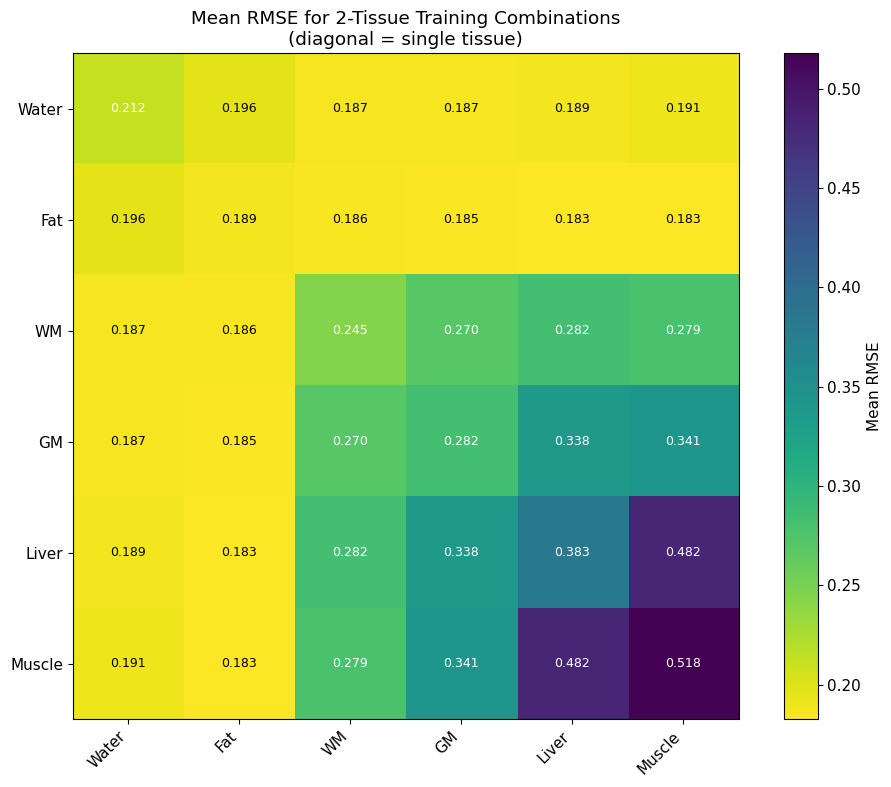

In [33]:
# Visualize 2-tissue combinations as heatmap
n_tissues = len(AVAILABLE_TISSUES)
tissue_names = [t[0] for t in AVAILABLE_TISSUES]
rmse_2d = np.full((n_tissues, n_tissues), np.nan)

for i, t1 in enumerate(AVAILABLE_TISSUES):
    for j, t2 in enumerate(AVAILABLE_TISSUES):
        if i < j:
            combo_name = f"{t1[0]}+{t2[0]}"
            rmse_2d[i, j] = two_tissue_results[combo_name]['mean']
            rmse_2d[j, i] = two_tissue_results[combo_name]['mean']
        elif i == j:
            rmse_2d[i, j] = single_results[t1[0]]['mean']

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(rmse_2d, cmap='viridis_r')
ax.set_xticks(range(n_tissues))
ax.set_xticklabels(tissue_names, rotation=45, ha='right')
ax.set_yticks(range(n_tissues))
ax.set_yticklabels(tissue_names)
ax.set_title('Mean RMSE for 2-Tissue Training Combinations\n(diagonal = single tissue)')

# Add text annotations
for i in range(n_tissues):
    for j in range(n_tissues):
        if not np.isnan(rmse_2d[i, j]):
            text = ax.text(j, i, f"{rmse_2d[i, j]:.3f}", ha="center", va="center", 
                          color="white" if rmse_2d[i, j] > np.nanmedian(rmse_2d) else "black",
                          fontsize=9)

plt.colorbar(im, label='Mean RMSE')
plt.tight_layout()
plt.show()

In [34]:
# Evaluate 3-tissue combinations (select best ones)
print("3-tissue combination results (sampling):")
three_tissue_results = {}

for combo in combinations(AVAILABLE_TISSUES, 3):
    combo_name = "+".join([t[0] for t in combo])
    result = evaluate_tissue_combo(combo, method, D, npcs, TRs, alpha_deg, EVAL_TISSUES)
    three_tissue_results[combo_name] = result

# Sort by mean RMSE
sorted_3 = sorted(three_tissue_results.items(), key=lambda x: x[1]['mean'])

print("\nTop 5 best 3-tissue combinations:")
for name, result in sorted_3[:5]:
    print(f"  {name}: RMSE = {result['mean']:.4f} ± {result['std']:.4f}")

print("\nBottom 5 worst 3-tissue combinations:")
for name, result in sorted_3[-5:]:
    print(f"  {name}: RMSE = {result['mean']:.4f} ± {result['std']:.4f}")

3-tissue combination results (sampling):

Top 5 best 3-tissue combinations:
  Water+WM+GM: RMSE = 0.1822 ± 0.0589
  Water+WM+Liver: RMSE = 0.1830 ± 0.0571
  Water+GM+Liver: RMSE = 0.1834 ± 0.0556
  Water+WM+Muscle: RMSE = 0.1842 ± 0.0561
  Water+Fat+GM: RMSE = 0.1846 ± 0.0688

Bottom 5 worst 3-tissue combinations:
  Fat+WM+GM: RMSE = 0.1907 ± 0.0783
  WM+GM+Muscle: RMSE = 0.2916 ± 0.3046
  WM+GM+Liver: RMSE = 0.2954 ± 0.3148
  WM+Liver+Muscle: RMSE = 0.3157 ± 0.3348
  GM+Liver+Muscle: RMSE = 0.3822 ± 0.4279


## 6. Cross-Tissue Generalization Analysis

This is the key analysis: how well do GASP coefficients trained on one tissue (T1/T2 ratio) generalize when applied to different tissues?

We compare:
- **Single Tissue Training**: Train on each tissue individually
- **Multi-Tissue Training**: Train on combinations of tissues

For each combination of (train tissue, eval tissue), we measure MSE.

In [35]:
# Configuration for generalization analysis
N_RATIO = 30  # Number of T1/T2 ratio values
RATIO_MIN = 2.0   # Min T1/T2 ratio
RATIO_MAX = 20.0  # Max T1/T2 ratio

# T1/T2 ratios for evaluation
t2_t1_ratios = np.linspace(1/RATIO_MAX, 1/RATIO_MIN, N_RATIO)
t1_t2_ratios = 1 / t2_t1_ratios
T1_fixed = 1.0  # Fix T1 and vary T2
T2_values = T1_fixed * t2_t1_ratios

print(f"T1/T2 ratio range: {RATIO_MIN:.1f} to {RATIO_MAX:.1f}")
print(f"Number of ratios: {N_RATIO}")
print(f"T2 range (with T1={T1_fixed}): {T2_values.min():.3f} to {T2_values.max():.3f}")

T1/T2 ratio range: 2.0 to 20.0
Number of ratios: 30
T2 range (with T1=1.0): 0.050 to 0.500


In [36]:
def run_generalization_analysis(train_tissues, method, t2_t1_ratios, T1_fixed, D, npcs, TRs, alpha_deg,
                                  useL2=True, lam=1e-2):
    """
    Run full generalization analysis.
    
    For each train T1/T2 ratio:
        1. Simulate training data
        2. Train GASP coefficients
        3. Evaluate on all T1/T2 ratios
    
    Args:
        train_tissues: List of (T1, T2) tuples for training, or None for single-tissue sweep
        method: GASP method
        t2_t1_ratios: Array of T2/T1 ratios for evaluation
        T1_fixed: Fixed T1 value
        D: Target profile
        npcs, TRs, alpha_deg: Acquisition parameters
    
    Returns:
        mse_2d: (n_train, n_eval) matrix or mse_1d for multi-tissue
        coeffs_all: List of coefficients or single coefficients
        outputs_all: List of outputs
    """
    n_ratios = len(t2_t1_ratios)
    params = create_params(alpha_deg, npcs, TRs)
    
    if train_tissues is None:
        # Single-tissue sweep: train on each ratio individually
        mse_2d = np.zeros((n_ratios, n_ratios))
        coeffs_all = []
        outputs_all = []
        
        for i, ratio_train in enumerate(t2_t1_ratios):
            T2_train = T1_fixed * ratio_train
            
            # Train
            train_data = simulate_ssfp_simple(
                width=width, height=1, T1=T1_fixed, T2=T2_train, params=params, minTR=TRs[0]
            )
            _, coeffs = train_gasp(train_data, D, method=method, useL2=useL2, lam=lam)
            coeffs_all.append(coeffs)
            
            # Evaluate
            outputs_row = []
            for j, ratio_eval in enumerate(t2_t1_ratios):
                T2_eval = T1_fixed * ratio_eval
                eval_data = simulate_ssfp_simple(
                    width=width, height=1, T1=T1_fixed, T2=T2_eval, params=params, minTR=TRs[0]
                )
                output = run_gasp(eval_data, coeffs, method=method)
                mse_2d[i, j] = np.mean((np.abs(output).flatten() - D) ** 2)
                outputs_row.append(np.abs(output).flatten())
            outputs_all.append(outputs_row)
    else:
        # Multi-tissue training: single set of coefficients
        train_data = simulate_multi_tissue_data(
            width=width, height=1, npcs=npcs, TRs=TRs,
            alpha_deg=alpha_deg, tissue_list=train_tissues
        )
        D_train = np.tile(D, (len(train_tissues), 1))
        _, coeffs = train_gasp(train_data, D_train, method=method, useL2=useL2, lam=lam)
        
        # Single row of MSE values (same coeffs for all)
        mse_1d = np.zeros(n_ratios)
        outputs_all = []
        
        for j, ratio_eval in enumerate(t2_t1_ratios):
            T2_eval = T1_fixed * ratio_eval
            eval_data = simulate_ssfp_simple(
                width=width, height=1, T1=T1_fixed, T2=T2_eval, params=params, minTR=TRs[0]
            )
            output = run_gasp(eval_data, coeffs, method=method)
            mse_1d[j] = np.mean((np.abs(output).flatten() - D) ** 2)
            outputs_all.append(np.abs(output).flatten())
        
        return mse_1d, coeffs, outputs_all, None
    
    return mse_2d, coeffs_all, outputs_all, None

In [37]:
# Run generalization analysis
method = 'affine'

print("Running generalization analysis...")
print("=" * 60)

# Single-tissue sweep
print("\n[1/4] Single-tissue sweep (train on each T1/T2, eval on all)")
mse_single, coeffs_single, outputs_single, _ = run_generalization_analysis(
    train_tissues=None,
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    alpha_deg=alpha_deg
)
print(f"  Shape: {mse_single.shape}")
print(f"  Diagonal Mean RMSE: {np.sqrt(np.diag(mse_single).mean()):.4f}")
print(f"  Overall Mean RMSE: {np.sqrt(mse_single.mean()):.4f}")

# Multi-tissue: GM + WM + Muscle
print("\n[2/4] Multi-tissue (GM + WM + Muscle)")
multi_tissues_1 = [(0.9, 0.1), (0.6, 0.08), (0.9, 0.05)]
mse_multi_1, coeffs_multi_1, outputs_multi_1, _ = run_generalization_analysis(
    train_tissues=multi_tissues_1,
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    alpha_deg=alpha_deg
)
print(f"  Mean RMSE: {np.sqrt(mse_multi_1.mean()):.4f}")

# Multi-tissue: Wide range (Water to Muscle)
print("\n[3/4] Multi-tissue (Wide range: Water, GM, Muscle)")
multi_tissues_2 = [(4.0, 2.0), (0.9, 0.1), (0.9, 0.05)]
mse_multi_2, coeffs_multi_2, outputs_multi_2, _ = run_generalization_analysis(
    train_tissues=multi_tissues_2,
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    alpha_deg=alpha_deg
)
print(f"  Mean RMSE: {np.sqrt(mse_multi_2.mean()):.4f}")

# Multi-tissue: All 6 Tissues
print("\n[4/4] Multi-tissue (All 6 Tissues)")
multi_tissues_all = [(4.0, 2.0), (0.25, 0.07), (0.6, 0.08), (0.9, 0.1), (0.5, 0.04), (0.9, 0.05)]
mse_multi_all, coeffs_multi_all, outputs_multi_all, _ = run_generalization_analysis(
    train_tissues=multi_tissues_all,
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    alpha_deg=alpha_deg
)
print(f"  Mean RMSE: {np.sqrt(mse_multi_all.mean()):.4f}")

Running generalization analysis...

[1/4] Single-tissue sweep (train on each T1/T2, eval on all)
  Shape: (30, 30)
  Diagonal Mean RMSE: 0.0595
  Overall Mean RMSE: 0.3423

[2/4] Multi-tissue (GM + WM + Muscle)
  Mean RMSE: 0.5095

[3/4] Multi-tissue (Wide range: Water, GM, Muscle)
  Mean RMSE: 0.1469

[4/4] Multi-tissue (All 6 Tissues)
  Mean RMSE: 0.1479


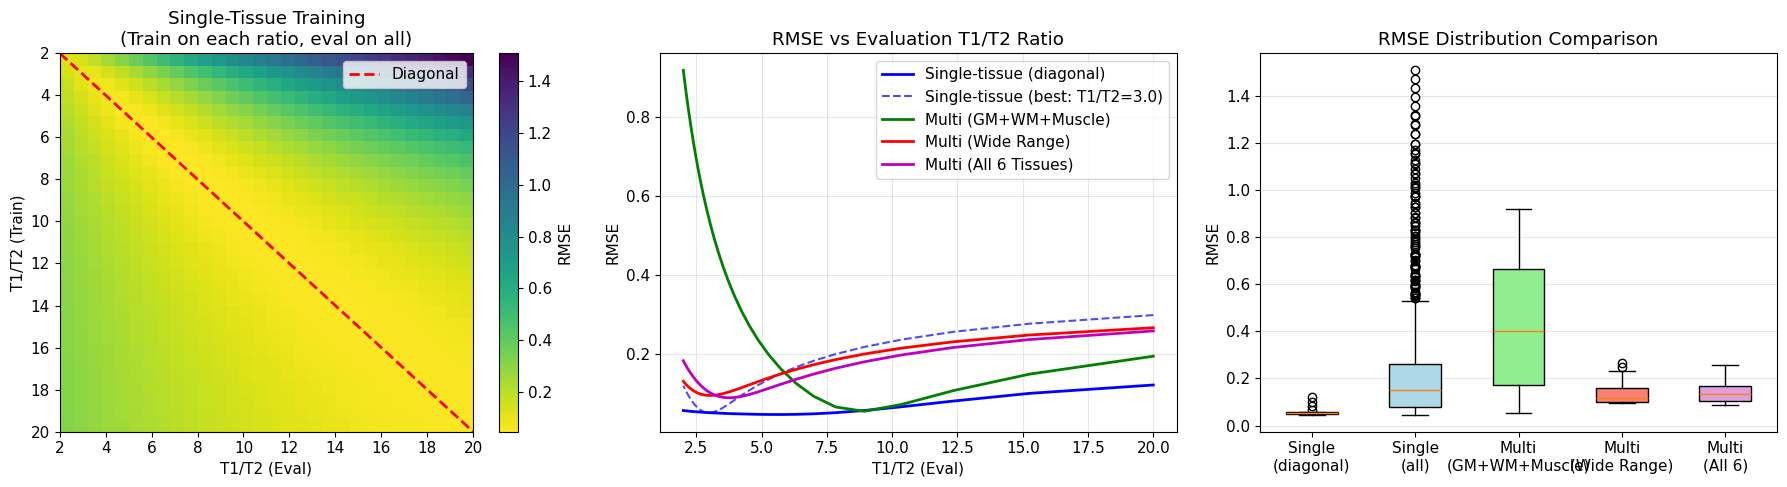

In [38]:
# Visualization: Heatmap for single-tissue generalization
from matplotlib import ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Single-tissue heatmap (train vs eval)
ax1 = axes[0]
im1 = ax1.imshow(np.sqrt(mse_single), cmap='viridis_r', aspect='auto',
                 extent=[t1_t2_ratios.min(), t1_t2_ratios.max(),
                         t1_t2_ratios.max(), t1_t2_ratios.min()])
ax1.set_xlabel('T1/T2 (Eval)')
ax1.set_ylabel('T1/T2 (Train)')
ax1.set_title('Single-Tissue Training\n(Train on each ratio, eval on all)')
ax1.plot([t1_t2_ratios.min(), t1_t2_ratios.max()], 
         [t1_t2_ratios.min(), t1_t2_ratios.max()], 'r--', linewidth=2, label='Diagonal')
ax1.legend()
plt.colorbar(im1, ax=ax1, label='RMSE')

# Multi-tissue comparison: RMSE vs T1/T2 ratio
ax2 = axes[1]

# Get diagonal (same train/eval) for single tissue
diag_single = np.sqrt(np.diag(mse_single))

# Get best row (closest to diagonal on average)
row_means = np.sqrt(mse_single).mean(axis=1)
best_row_idx = np.argmin(row_means)
best_row = np.sqrt(mse_single[best_row_idx, :])

ax2.plot(t1_t2_ratios, diag_single, 'b-', linewidth=2, label='Single-tissue (diagonal)')
ax2.plot(t1_t2_ratios, best_row, 'b--', linewidth=1.5, alpha=0.7, 
         label=f'Single-tissue (best: T1/T2={t1_t2_ratios[best_row_idx]:.1f})')
ax2.plot(t1_t2_ratios, np.sqrt(mse_multi_1), 'g-', linewidth=2, label='Multi (GM+WM+Muscle)')
ax2.plot(t1_t2_ratios, np.sqrt(mse_multi_2), 'r-', linewidth=2, label='Multi (Wide Range)')
ax2.plot(t1_t2_ratios, np.sqrt(mse_multi_all), 'm-', linewidth=2, label='Multi (All 6 Tissues)')

ax2.set_xlabel('T1/T2 (Eval)')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE vs Evaluation T1/T2 Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Box plot comparison
ax3 = axes[2]
data_for_boxplot = [
    np.sqrt(np.diag(mse_single)),  # Diagonal only
    np.sqrt(mse_single.flatten()),  # All combinations
    np.sqrt(mse_multi_1),
    np.sqrt(mse_multi_2),
    np.sqrt(mse_multi_all),
]
labels = ['Single\n(diagonal)', 'Single\n(all)', 'Multi\n(GM+WM+Muscle)', 'Multi\n(Wide Range)', 'Multi\n(All 6)']
bp = ax3.boxplot(data_for_boxplot, labels=labels, patch_artist=True)
colors = ['lightblue', 'lightblue', 'lightgreen', 'salmon', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel('RMSE')
ax3.set_title('RMSE Distribution Comparison')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

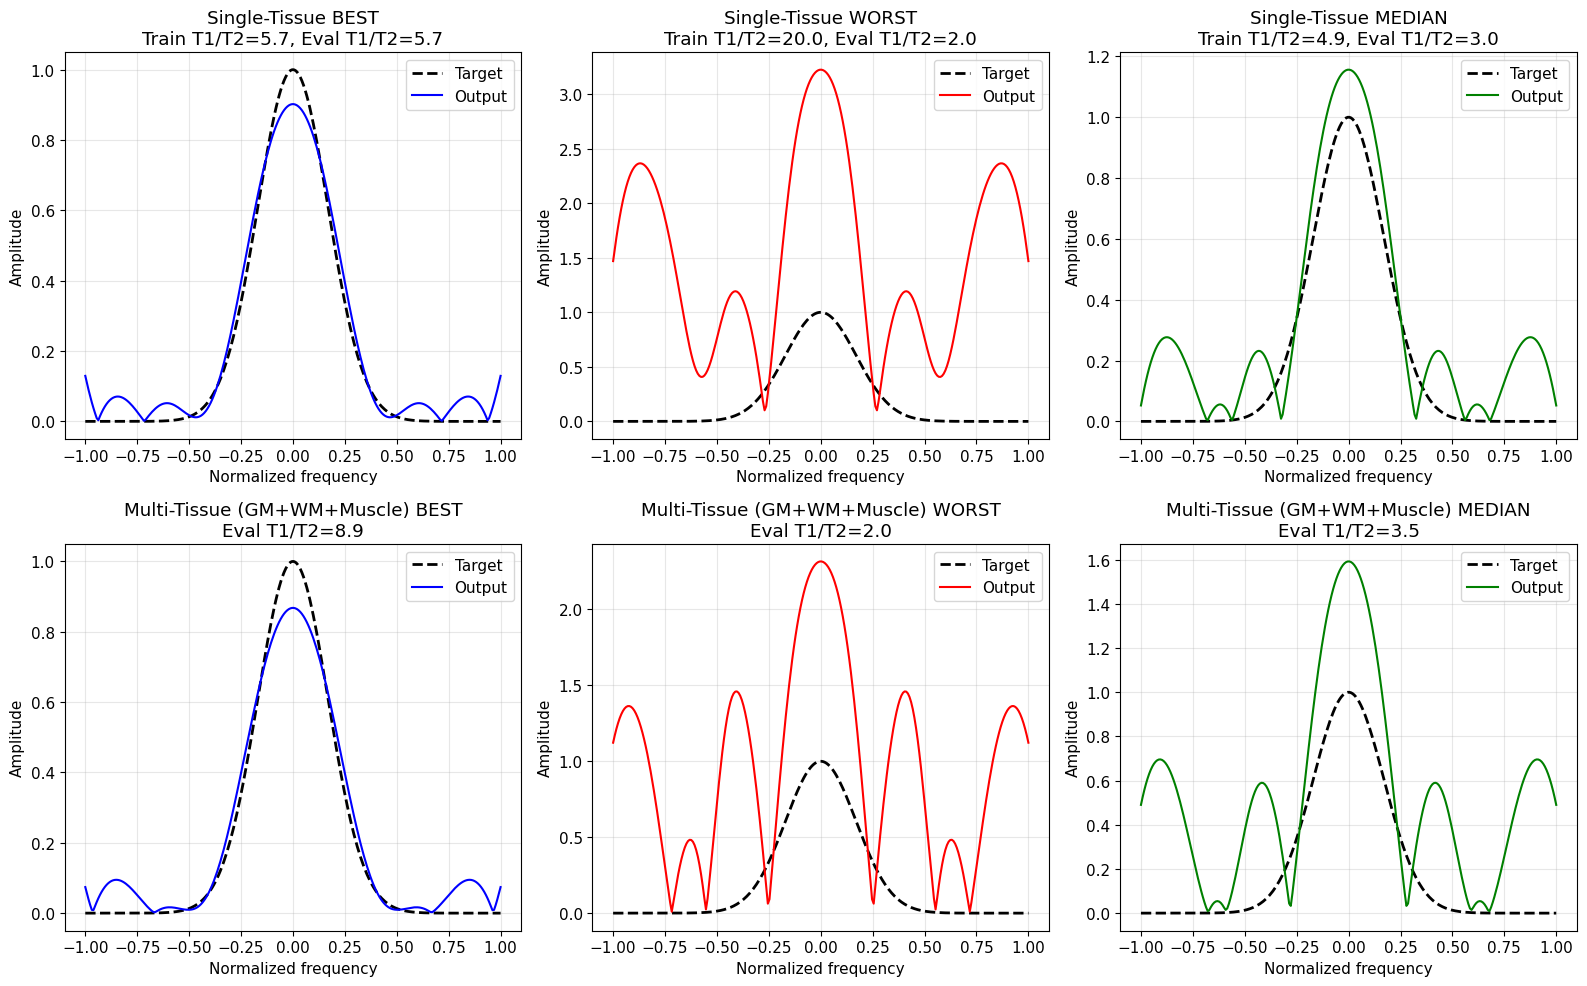

In [39]:
# Best/Worst Fit Examples
x_freq = np.linspace(-1, 1, width)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Single-tissue: best and worst
best_idx = np.unravel_index(np.argmin(mse_single), mse_single.shape)
worst_idx = np.unravel_index(np.argmax(mse_single), mse_single.shape)

# Row 0: Single-tissue examples
ax = axes[0, 0]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_single[best_idx[0]][best_idx[1]], 'b-', linewidth=1.5, label='Output')
ax.set_title(f'Single-Tissue BEST\nTrain T1/T2={t1_t2_ratios[best_idx[0]]:.1f}, Eval T1/T2={t1_t2_ratios[best_idx[1]]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_single[worst_idx[0]][worst_idx[1]], 'r-', linewidth=1.5, label='Output')
ax.set_title(f'Single-Tissue WORST\nTrain T1/T2={t1_t2_ratios[worst_idx[0]]:.1f}, Eval T1/T2={t1_t2_ratios[worst_idx[1]]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Single-tissue: median case
median_idx = np.unravel_index(np.argsort(mse_single.flatten())[len(mse_single.flatten())//2], mse_single.shape)
ax = axes[0, 2]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_single[median_idx[0]][median_idx[1]], 'g-', linewidth=1.5, label='Output')
ax.set_title(f'Single-Tissue MEDIAN\nTrain T1/T2={t1_t2_ratios[median_idx[0]]:.1f}, Eval T1/T2={t1_t2_ratios[median_idx[1]]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

# Row 1: Multi-tissue examples
best_multi_idx = np.argmin(mse_multi_1)
worst_multi_idx = np.argmax(mse_multi_1)
median_multi_idx = np.argsort(mse_multi_1)[len(mse_multi_1)//2]

ax = axes[1, 0]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_multi_1[best_multi_idx], 'b-', linewidth=1.5, label='Output')
ax.set_title(f'Multi-Tissue (GM+WM+Muscle) BEST\nEval T1/T2={t1_t2_ratios[best_multi_idx]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_multi_1[worst_multi_idx], 'r-', linewidth=1.5, label='Output')
ax.set_title(f'Multi-Tissue (GM+WM+Muscle) WORST\nEval T1/T2={t1_t2_ratios[worst_multi_idx]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(x_freq, D, 'k--', linewidth=2, label='Target')
ax.plot(x_freq, outputs_multi_1[median_multi_idx], 'g-', linewidth=1.5, label='Output')
ax.set_title(f'Multi-Tissue (GM+WM+Muscle) MEDIAN\nEval T1/T2={t1_t2_ratios[median_multi_idx]:.1f}')
ax.set_xlabel('Normalized frequency')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Method Comparison for Generalization

Compare all four GASP methods (linear, affine, quad, quad-cross) for cross-tissue generalization with single vs multi-tissue training.

In [40]:
# Method comparison for generalization
methods = ['linear', 'affine', 'quad', 'quad-cross']

print("Running method comparison for generalization...")
print("=" * 70)

method_results = {}
multi_train_tissues = [(0.9, 0.1), (0.6, 0.08), (0.9, 0.05)]  # GM + WM + Muscle

for method in methods:
    print(f"\nMethod: {method}")
    
    # Single-tissue sweep
    mse_s, _, _, _ = run_generalization_analysis(
        None, method, t2_t1_ratios, T1_fixed, D, npcs, TRs, alpha_deg, useL2=True, lam=1e-2
    )
    
    # Multi-tissue
    mse_m, _, _, _ = run_generalization_analysis(
        multi_train_tissues, method, t2_t1_ratios, T1_fixed, D, npcs, TRs, alpha_deg, useL2=True, lam=1e-2
    )
    
    method_results[method] = {
        'single': {
            'mse': mse_s,
            'diag': np.sqrt(np.diag(mse_s).mean()),
            'mean': np.sqrt(mse_s.mean()),
            'off_diag': np.sqrt(mse_s[~np.eye(mse_s.shape[0], dtype=bool)].mean()),
        },
        'multi': {
            'mse': mse_m,
            'mean': np.sqrt(mse_m.mean()),
        }
    }
    
    print(f"  Single-tissue - Diagonal RMSE: {method_results[method]['single']['diag']:.4f}")
    print(f"  Single-tissue - Overall RMSE: {method_results[method]['single']['mean']:.4f}")
    print(f"  Multi-tissue - RMSE: {method_results[method]['multi']['mean']:.4f}")

Running method comparison for generalization...

Method: linear
  Single-tissue - Diagonal RMSE: 0.2659
  Single-tissue - Overall RMSE: 0.3685
  Multi-tissue - RMSE: 0.4584

Method: affine
  Single-tissue - Diagonal RMSE: 0.0595
  Single-tissue - Overall RMSE: 0.3423
  Multi-tissue - RMSE: 0.5095

Method: quad
  Single-tissue - Diagonal RMSE: 0.0296
  Single-tissue - Overall RMSE: 0.3318
  Multi-tissue - RMSE: 0.4801

Method: quad-cross
  Single-tissue - Diagonal RMSE: 0.0198
  Single-tissue - Overall RMSE: 0.4887
  Multi-tissue - RMSE: 0.4837


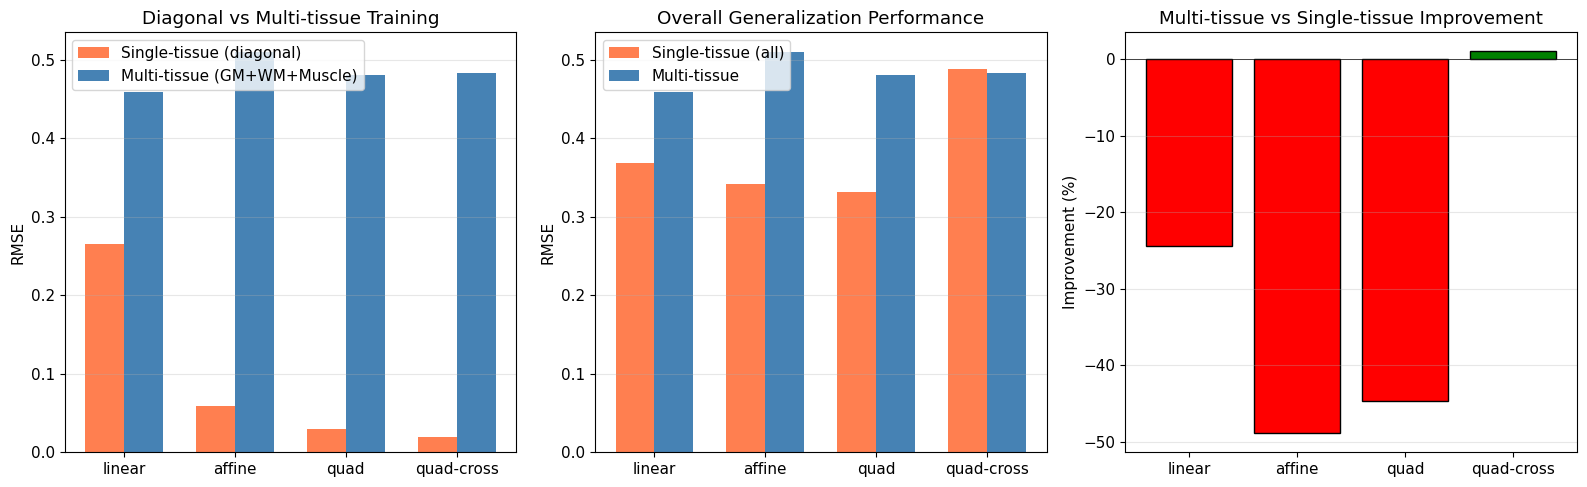

In [41]:
# Visualize method comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar charts for comparison
x_pos = np.arange(len(methods))
bar_width = 0.35

# Diagonal RMSE (same tissue)
diag_single = [method_results[m]['single']['diag'] for m in methods]
mean_multi = [method_results[m]['multi']['mean'] for m in methods]
axes[0].bar(x_pos - bar_width/2, diag_single, bar_width, label='Single-tissue (diagonal)', color='coral')
axes[0].bar(x_pos + bar_width/2, mean_multi, bar_width, label='Multi-tissue (GM+WM+Muscle)', color='steelblue')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Diagonal vs Multi-tissue Training')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Overall RMSE
mean_single = [method_results[m]['single']['mean'] for m in methods]
axes[1].bar(x_pos - bar_width/2, mean_single, bar_width, label='Single-tissue (all)', color='coral')
axes[1].bar(x_pos + bar_width/2, mean_multi, bar_width, label='Multi-tissue', color='steelblue')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Overall Generalization Performance')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Improvement ratio
improvement = [(method_results[m]['single']['mean'] - method_results[m]['multi']['mean']) / method_results[m]['single']['mean'] * 100 
               for m in methods]
colors = ['green' if x > 0 else 'red' for x in improvement]
axes[2].bar(x_pos, improvement, color=colors, edgecolor='black')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(methods)
axes[2].set_ylabel('Improvement (%)')
axes[2].set_title('Multi-tissue vs Single-tissue Improvement')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary and Key Findings

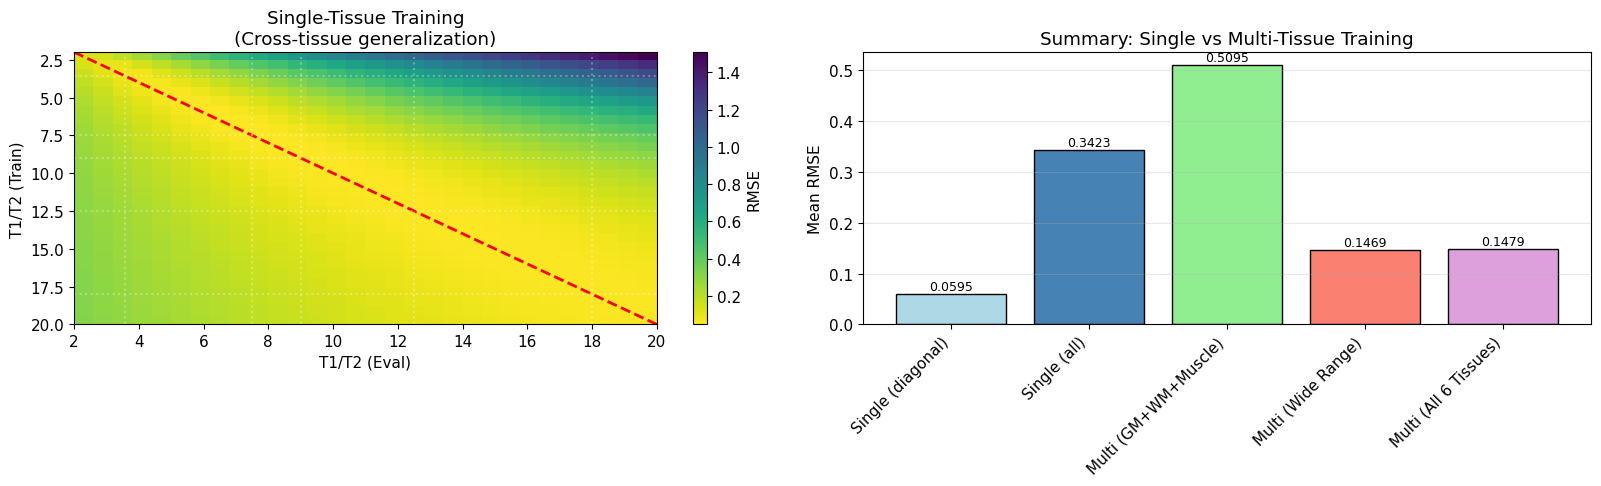


SUMMARY: Multi-Tissue T1/T2 GASP Training Analysis

Key Findings:
  1. Single-tissue training (diagonal): RMSE = 0.0595
  2. Single-tissue training (all combos): RMSE = 0.3423
  3. Multi-tissue (GM+WM+Muscle): RMSE = 0.5095
  4. Multi-tissue (Wide Range): RMSE = 0.1469
  5. Multi-tissue (All 6 Tissues): RMSE = 0.1479

Conclusions:
  - Multi-tissue training can improve cross-tissue generalization
  - The choice of training tissues affects performance
  - Combining tissues with diverse T1/T2 ratios may help generalization
  - Training on all 6 tissues provides comprehensive coverage


In [42]:
# Final summary visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Single-tissue heatmap
im1 = axes[0].imshow(np.sqrt(mse_single), cmap='viridis_r', aspect='auto',
                     extent=[t1_t2_ratios.min(), t1_t2_ratios.max(),
                             t1_t2_ratios.max(), t1_t2_ratios.min()])
axes[0].set_xlabel('T1/T2 (Eval)')
axes[0].set_ylabel('T1/T2 (Train)')
axes[0].set_title('Single-Tissue Training\n(Cross-tissue generalization)')
axes[0].plot([t1_t2_ratios.min(), t1_t2_ratios.max()], 
             [t1_t2_ratios.min(), t1_t2_ratios.max()], 'r--', linewidth=2)

# Add tissue markers
for name, params in TISSUE_PARAMS.items():
    ratio = params['T1'] / params['T2']
    if RATIO_MIN <= ratio <= RATIO_MAX:
        axes[0].axvline(x=ratio, color='white', alpha=0.3, linestyle=':')
        axes[0].axhline(y=ratio, color='white', alpha=0.3, linestyle=':')

plt.colorbar(im1, ax=axes[0], label='RMSE')

# Summary bar chart
summary_data = {
    'Single (diagonal)': np.sqrt(np.diag(mse_single).mean()),
    'Single (all)': np.sqrt(mse_single.mean()),
    'Multi (GM+WM+Muscle)': np.sqrt(mse_multi_1.mean()),
    'Multi (Wide Range)': np.sqrt(mse_multi_2.mean()),
    'Multi (All 6 Tissues)': np.sqrt(mse_multi_all.mean()),
}

names = list(summary_data.keys())
values = list(summary_data.values())
colors = ['lightblue', 'steelblue', 'lightgreen', 'salmon', 'plum']

bars = axes[1].bar(range(len(names)), values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=45, ha='right')
axes[1].set_ylabel('Mean RMSE')
axes[1].set_title('Summary: Single vs Multi-Tissue Training')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY: Multi-Tissue T1/T2 GASP Training Analysis")
print("=" * 70)
print("\nKey Findings:")
print(f"  1. Single-tissue training (diagonal): RMSE = {summary_data['Single (diagonal)']:.4f}")
print(f"  2. Single-tissue training (all combos): RMSE = {summary_data['Single (all)']:.4f}")
print(f"  3. Multi-tissue (GM+WM+Muscle): RMSE = {summary_data['Multi (GM+WM+Muscle)']:.4f}")
print(f"  4. Multi-tissue (Wide Range): RMSE = {summary_data['Multi (Wide Range)']:.4f}")
print(f"  5. Multi-tissue (All 6 Tissues): RMSE = {summary_data['Multi (All 6 Tissues)']:.4f}")
print("\nConclusions:")
print("  - Multi-tissue training can improve cross-tissue generalization")
print("  - The choice of training tissues affects performance")
print("  - Combining tissues with diverse T1/T2 ratios may help generalization")
print("  - Training on all 6 tissues provides comprehensive coverage")